PyTorch version: 2.12.1+cpu
Device: cpu

Extracting dataset...

Total reviews: 50000
Vocabulary size: 20000

Training samples: 36000
Validation samples: 4000
Testing samples: 10000


C:\Users\acer\anaconda3\envs\pytorch_env\Lib\site-packages\torch\nn\modules\rnn.py:1009: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)



Training LSTM model...

Epoch 1/3 - Training Loss: 0.6897 - Validation Loss: 0.6593
Epoch 2/3 - Training Loss: 0.6844 - Validation Loss: 0.6252
Epoch 3/3 - Training Loss: 0.6810 - Validation Loss: 0.6847

========== MODEL EVALUATION ==========
Accuracy  : 54.79%
Precision : 53.51%
Recall    : 72.96%
F1-Score  : 61.74%


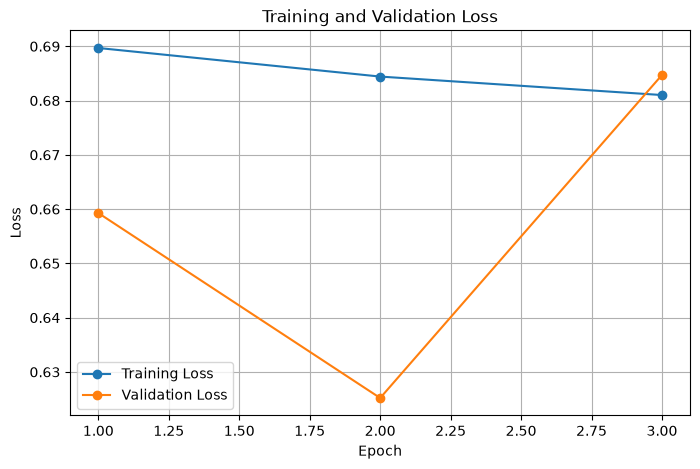


========== NEW REVIEW ==========


In [ ]:
import sys
import subprocess
import os
import re
import urllib.request
import tarfile
import random
from collections import Counter

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "scikit-learn", "matplotlib"])

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

random.seed(42)
torch.manual_seed(42)

dataset_url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
dataset_file = "aclImdb_v1.tar.gz"

if not os.path.exists("aclImdb"):
    print("\nDownloading IMDb 50K dataset...")
    urllib.request.urlretrieve(dataset_url, dataset_file)

    print("Extracting dataset...")
    with tarfile.open(dataset_file, "r:gz") as tar:
        tar.extractall()

reviews = []
labels = []

for split in ["train", "test"]:
    for sentiment, label in [("pos", 1), ("neg", 0)]:
        folder = os.path.join("aclImdb", split, sentiment)

        for filename in os.listdir(folder):
            if filename.endswith(".txt"):
                filepath = os.path.join(folder, filename)

                with open(filepath, "r", encoding="utf-8") as f:
                    review = f.read()

                reviews.append(review)
                labels.append(label)

print("\nTotal reviews:", len(reviews))

def clean_and_tokenize(text):
    text = text.lower()
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"[^a-zA-Z0-9\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text.split()

tokenized_reviews = [clean_and_tokenize(review) for review in reviews]

vocab_size = 20000
max_length = 200

word_counter = Counter()

for tokens in tokenized_reviews:
    word_counter.update(tokens)

vocab = {
    "<PAD>": 0,
    "<UNK>": 1
}

for word, count in word_counter.most_common(vocab_size - 2):
    vocab[word] = len(vocab)

print("Vocabulary size:", len(vocab))

def encode_review(tokens):
    sequence = [vocab.get(word, vocab["<UNK>"]) for word in tokens]

    if len(sequence) > max_length:
        sequence = sequence[:max_length]

    if len(sequence) < max_length:
        sequence += [vocab["<PAD>"]] * (max_length - len(sequence))

    return sequence

encoded_reviews = [encode_review(tokens) for tokens in tokenized_reviews]

X = torch.tensor(encoded_reviews, dtype=torch.long)
y = torch.tensor(labels, dtype=torch.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.10,
    random_state=42,
    stratify=y_train
)

print("\nTraining samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Testing samples:", len(X_test))

class IMDbDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.y[index]

batch_size = 64

train_dataset = IMDbDataset(X_train, y_train)
val_dataset = IMDbDataset(X_val, y_val)
test_dataset = IMDbDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=128):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            dropout=0.2
        )

        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        embedded = self.embedding(x)

        output, (hidden, cell) = self.lstm(embedded)

        hidden = hidden[-1]

        output = self.fc(hidden)

        return output.squeeze(1)

model = LSTMModel(len(vocab)).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 3

train_losses = []
val_losses = []

print("\nTraining LSTM model...\n")

for epoch in range(epochs):

    model.train()

    total_train_loss = 0

    for batch_x, batch_y in train_loader:

        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        predictions = model(batch_x)

        loss = criterion(predictions, batch_y)

        loss.backward()

        optimizer.step()

        total_train_loss += loss.item()

    train_loss = total_train_loss / len(train_loader)

    model.eval()

    total_val_loss = 0

    with torch.no_grad():

        for batch_x, batch_y in val_loader:

            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            predictions = model(batch_x)

            loss = criterion(predictions, batch_y)

            total_val_loss += loss.item()

    val_loss = total_val_loss / len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch + 1}/{epochs} "
        f"- Training Loss: {train_loss:.4f} "
        f"- Validation Loss: {val_loss:.4f}"
    )

model.eval()

all_predictions = []
all_actual = []

with torch.no_grad():

    for batch_x, batch_y in test_loader:

        batch_x = batch_x.to(device)

        outputs = model(batch_x)

        probabilities = torch.sigmoid(outputs)

        predictions = (probabilities >= 0.5).int()

        all_predictions.extend(predictions.cpu().numpy())
        all_actual.extend(batch_y.numpy())

accuracy = accuracy_score(all_actual, all_predictions)
precision = precision_score(all_actual, all_predictions)
recall = recall_score(all_actual, all_predictions)
f1 = f1_score(all_actual, all_predictions)

print("\n========== MODEL EVALUATION ==========")
print(f"Accuracy  : {accuracy * 100:.2f}%")
print(f"Precision : {precision * 100:.2f}%")
print(f"Recall    : {recall * 100:.2f}%")
print(f"F1-Score  : {f1 * 100:.2f}%")

plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_losses, marker="o", label="Training Loss")
plt.plot(range(1, epochs + 1), val_losses, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

def predict_sentiment(review):

    tokens = clean_and_tokenize(review)

    sequence = encode_review(tokens)

    input_tensor = torch.tensor(
        [sequence],
        dtype=torch.long
    ).to(device)

    model.eval()

    with torch.no_grad():

        output = model(input_tensor)

        probability = torch.sigmoid(output).item()

    if probability >= 0.5:
        sentiment = "Positive"
        confidence = probability * 100
    else:
        sentiment = "Negative"
        confidence = (1 - probability) * 100

    print("\nPredicted Sentiment:", sentiment)
    print(f"Confidence: {confidence:.2f}%")

print("\n========== NEW REVIEW ==========")

user_review = input("Enter a movie review: ")

predict_sentiment(user_review)